In [1]:
# 학습된 대형모델(백본)인 MobileNet v2를 전이학습하여 cifar10 dataset을 분류하기
# 전이학습(Tansfer Learning) - 이미 학습된 모델을 일부 재학습하여

import tensorflow as tf

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

NUM_CLASSES = 10

y_train = tf.keras.utils.to_categorical(y_train, NUM_CLASSES) # 원핫인코딩
y_test = tf.keras.utils.to_categorical(y_test, NUM_CLASSES)

print('train data : ', x_train.shape, y_train.shape)
print('test data : ', x_test.shape, y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 15s 0us/step
train data :  (50000, 32, 32, 3) (50000, 10)
test data :  (10000, 32, 32, 3) (10000, 10)


In [2]:
# 전이학습 기존 모델의(백본)의 가중치는 모두 동결(freeze)
base_model = tf.keras.applications.MobileNetV2(
    input_shape = (128,128, 3), # 입력 크기 96, 128, 160, 192, 224 등을 지원
    include_top = False,    # MobileNetV2의 분류기 부분을 뺌. 컨볼루션 레이어만 남김
    weights = 'imagenet',   # 사전 학습된 가중치 호출(120만 이미지, 1000개의 클래스)
)

base_model.trainable = False # MobileNetV2은 학습에 참여하지 않도록 동결
print(base_model.summary())

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "mobilenetv2_1.00_128"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

None


In [3]:
# MobileNetV2을 이용해 새로운 모델 생성
inputs = tf.keras.Input(shape=(32, 32, 3))
x = tf.keras.layers.Resizing(128, 128)(inputs)   # cifar10 이미지를 mobileNetV2에 맞게 리사이징
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)  # MaxPooling2D 보다 더 급격하게 feature의 크기를 줄임
outputs = tf.keras.layers.Dense(units=NUM_CLASSES, activation='softmax')(x) # 새 분류기로 정의

model_tl = tf.keras.Model(inputs, outputs)

In [4]:
model_tl.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model_tl.fit(
    x_train,
    y_train,
    batch_size=64,
    epochs=10,
    validation_split=0.2,
    verbose=0
)

loss, acc = model_tl.evaluate(x_test, y_test, verbose=0)
print(f'loss :{loss:.4f}, acc : {acc:.4f}')

loss :0.6202, acc : 0.7839


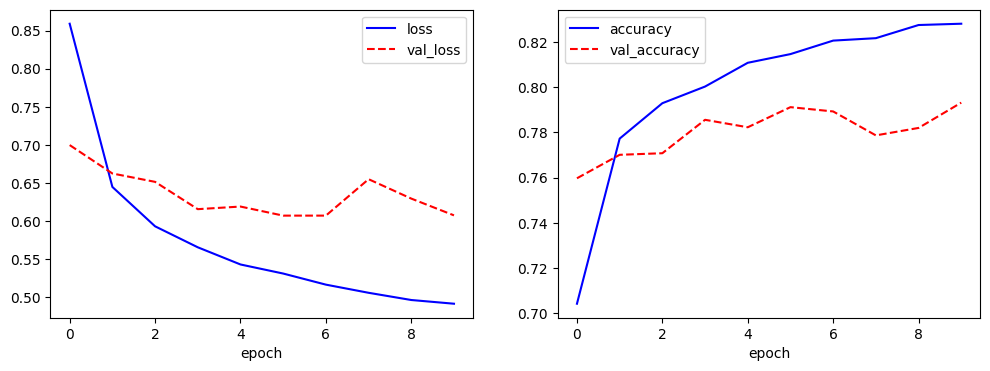

In [6]:
# 성능 시각화
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], 'b-', label='loss')
plt.plot(history.history['val_loss'], 'r--', label='val_loss')
plt.xlabel('epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], 'b-', label='accuracy')
plt.plot(history.history['val_accuracy'], 'r--', label='val_accuracy')
plt.xlabel('epoch')
plt.legend()
plt.show()

In [7]:
# 미세 조정(Fine Tunning) - 전이 학습 이후 성능 향상을 위해 백본의 일부층을 학습에 참여시킴
base_model.trainable = True           # 모델 전체 학습에 참여 가능
for layer in base_model.layers[:-10]: # 마지막 10개 층만 해제하고 나머지는 다시 동결
  layer.trainable = False

model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_tl.fit(
    x_train,
    y_train,
    batch_size=64,
    epochs=10,
    validation_split=0.2,
    verbose=0
)

loss, acc = model_tl.evaluate(x_test, y_test, verbose=0)
print(f'loss :{loss:.4f}, acc : {acc:.4f}')



loss :0.6505, acc : 0.8012
